In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '1'

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.utils.prune as prune
import torchvision.models as models

import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

from torch.optim.lr_scheduler import CosineAnnealingLR

In [3]:
# onnxファイルを作成する関数
def model_to_onnx(model, output_file, input_shape = (1, 3, 224, 224)):
  model.eval()
  input_tensor = torch.randn(input_shape).to('cpu')
  input_names = ['input']
  output_names = ['output']
  torch.onnx.export(model, input_tensor, output_file, verbose = False, input_names = input_names, output_names = output_names)
  return output_file

In [4]:
# モデル読み込み
pt_model_path = "../dense.pt"
model = models.resnet18(weights = "IMAGENET1K_V1")
model.fc = nn.Linear(model.fc.in_features, 10)  # CIFAR-10 にあわせて出力層変更
model.load_state_dict(torch.load(pt_model_path))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [5]:
# 訓練データセット作成
transform = transforms.Compose([transforms.Resize(224),
                                transforms.ToTensor(),
                                transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])   # 正規化したほうがいいらしい

trainset = torchvision.datasets.CIFAR10(root = "../data", train = True, download = True, transform = transform)
trainloader = DataLoader(trainset, batch_size = 400, shuffle = True)

In [6]:
# 枝刈り前のTVを見てみる

def Omega(delta):
    """
    4階テンソルdeltaの各次元に沿った差分を計算し、
    その絶対値の総和を返す。
    """
    h = 1.0  # Dのパラメータ

    # 4つの次元それぞれに対して差分（勾配）を計算

    # dim=0 (出力チャネル方向の差分)
    diff_dim0 = delta[1:, :, :, :] - delta[:-1, :, :, :]

    # dim=1 (入力チャネル方向の差分)
    diff_dim1 = delta[:, 1:, :, :] - delta[:, :-1, :, :]

    # dim=2 (縦方向の差分)
    # 1行目から最後までと、0行目から最後の一つ手前までの差
    diff_dim2 = delta[:, :, 1:, :] - delta[:, :, :-1, :]

    # dim=3 (横方向の差分)
    # 1列目から最後までと、0列目から最後の一つ手前までの差
    diff_dim3 = delta[:, :, :, 1:] - delta[:, :, :, :-1]

    # 全ての差分の絶対値の総和を計算
    # これがD@deltaに相当する操作のL1ノルムになる
    constrain = torch.sum(torch.abs(diff_dim0)) + torch.sum(torch.abs(diff_dim1)) + torch.sum(torch.abs(diff_dim2)) + torch.sum(torch.abs(diff_dim3))

    return constrain / h

layer_tvs = {}
layer_relative_tvs = {}
conv_layer_names = []

for name, module in model.named_modules():
    if isinstance(module, nn.Conv2d):
        w_tensor = module.weight.detach().clone().to(device)
        tv = Omega(w_tensor).item()
        ave_tv = tv/(w_tensor).numel()
        relative_tv = tv / torch.sum(torch.abs(w_tensor)).item()
        layer_tvs[name] = tv
        layer_relative_tvs[name] = relative_tv
        conv_layer_names.append(name)
        print(f"{name}：TV={tv:.4f}     ave_TV={ave_tv:.4f}     relative_TV={relative_tv:.4f}")

conv1：TV=2785.1948     ave_TV=0.2960     relative_TV=3.8864
layer1.0.conv1：TV=5368.6899     ave_TV=0.1456     relative_TV=4.6001
layer1.0.conv2：TV=5110.8359     ave_TV=0.1386     relative_TV=4.3279
layer1.1.conv1：TV=5665.4883     ave_TV=0.1537     relative_TV=4.4829
layer1.1.conv2：TV=5081.4331     ave_TV=0.1378     relative_TV=4.3692
layer2.0.conv1：TV=9606.8564     ave_TV=0.1303     relative_TV=4.4254
layer2.0.conv2：TV=15700.7480     ave_TV=0.1065     relative_TV=4.4383
layer2.0.downsample.0：TV=1077.2024     ave_TV=0.1315     relative_TV=2.9591
layer2.1.conv1：TV=16048.6338     ave_TV=0.1088     relative_TV=4.4778
layer2.1.conv2：TV=14007.5215     ave_TV=0.0950     relative_TV=4.2592
layer3.0.conv1：TV=24442.1191     ave_TV=0.0829     relative_TV=3.9467
layer3.0.conv2：TV=45506.3359     ave_TV=0.0772     relative_TV=4.1868
layer3.0.downsample.0：TV=2261.6729     ave_TV=0.0690     relative_TV=2.8949
layer3.1.conv1：TV=41485.1523     ave_TV=0.0703     relative_TV=4.2055
layer3.1.conv2：TV=37498

In [7]:
# すべての畳み込み層を枝刈り対象に
parameters_to_prune = [
    (module, "weight") for module in model.modules() if isinstance(module, torch.nn.Conv2d)
]

# 大域的・非構造・強度枝刈り
cut_rate = 0.99
prune.global_unstructured(
    parameters_to_prune,
    pruning_method = prune.L1Unstructured,
    amount = cut_rate,
)

In [8]:
# この後に非構造枝刈りを行うのでマスクとモデルのサイズが異なるのを防ぐために永続化（マスクと重みを掛ける）
for module in model.modules():
  if isinstance(module, torch.nn.Conv2d):
    prune.remove(module, "weight")

In [9]:
# ゼロ比率を表示
zero_ratings = {}
for name, module in model.named_modules():
  if isinstance(module, torch.nn.Conv2d):
    zero_ratings[name] = float(torch.sum(module.weight == 0)) / float(module.weight.nelement())
    print(f"{name} Zero-Ratio: {100.0 * zero_ratings[name]:.2f}%")

conv1 Zero-Ratio: 64.85%
layer1.0.conv1 Zero-Ratio: 87.69%
layer1.0.conv2 Zero-Ratio: 88.24%
layer1.1.conv1 Zero-Ratio: 87.16%
layer1.1.conv2 Zero-Ratio: 88.84%
layer2.0.conv1 Zero-Ratio: 90.21%
layer2.0.conv2 Zero-Ratio: 94.57%
layer2.0.downsample.0 Zero-Ratio: 80.92%
layer2.1.conv1 Zero-Ratio: 94.45%
layer2.1.conv2 Zero-Ratio: 96.19%
layer3.0.conv1 Zero-Ratio: 96.65%
layer3.0.conv2 Zero-Ratio: 98.05%
layer3.0.downsample.0 Zero-Ratio: 94.87%
layer3.1.conv1 Zero-Ratio: 98.77%
layer3.1.conv2 Zero-Ratio: 99.19%
layer4.0.conv1 Zero-Ratio: 99.44%
layer4.0.conv2 Zero-Ratio: 99.76%
layer4.0.downsample.0 Zero-Ratio: 95.11%
layer4.1.conv1 Zero-Ratio: 99.82%
layer4.1.conv2 Zero-Ratio: 99.92%


In [10]:
# 構造的かつ非構造枝刈りしたときのゼロ比率を表示
all_conv_params = 0
all_conv_zeros = 0

for name, module in model.named_modules():
  if isinstance(module, torch.nn.Conv2d):
    print(f"{name} Zero-Ratio: {100.0 * float(torch.sum(module.weight == 0)) / float(module.weight.nelement()):.4f}%")
    weight_after_pruning = module.weight
    num_zeros = (weight_after_pruning == 0).sum().item()
    total_params = weight_after_pruning.numel()
    all_conv_params += total_params
    all_conv_zeros += num_zeros

sparsity = 100. * all_conv_zeros / all_conv_params if all_conv_params > 0 else 0
print(f"全畳み込み層の0率：{sparsity:.4f}%")

print(model)

conv1 Zero-Ratio: 64.8491%
layer1.0.conv1 Zero-Ratio: 87.6926%
layer1.0.conv2 Zero-Ratio: 88.2433%
layer1.1.conv1 Zero-Ratio: 87.1609%
layer1.1.conv2 Zero-Ratio: 88.8428%
layer2.0.conv1 Zero-Ratio: 90.2100%
layer2.0.conv2 Zero-Ratio: 94.5685%
layer2.0.downsample.0 Zero-Ratio: 80.9204%
layer2.1.conv1 Zero-Ratio: 94.4539%
layer2.1.conv2 Zero-Ratio: 96.1934%
layer3.0.conv1 Zero-Ratio: 96.6485%
layer3.0.conv2 Zero-Ratio: 98.0450%
layer3.0.downsample.0 Zero-Ratio: 94.8669%
layer3.1.conv1 Zero-Ratio: 98.7700%
layer3.1.conv2 Zero-Ratio: 99.1911%
layer4.0.conv1 Zero-Ratio: 99.4364%
layer4.0.conv2 Zero-Ratio: 99.7595%
layer4.0.downsample.0 Zero-Ratio: 95.1149%
layer4.1.conv1 Zero-Ratio: 99.8160%
layer4.1.conv2 Zero-Ratio: 99.9205%
全畳み込み層の0率：99.0000%
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=

In [11]:
# 強度枝刈り後のTVを見る

layer_tvs = {}
layer_relative_tvs = {}
conv_layer_names = []

for name, module in model.named_modules():
    if isinstance(module, nn.Conv2d):
        w_tensor = module.weight.detach().clone().to(device)
        tv = Omega(w_tensor).item()
        ave_tv = tv/(w_tensor).numel()
        relative_tv = tv / torch.sum(torch.abs(w_tensor)).item()
        layer_tvs[name] = tv
        layer_relative_tvs[name] = relative_tv
        conv_layer_names.append(name)
        print(f"{name}：TV={tv:.4f}     ave_TV={ave_tv:.4f}     relative_TV={relative_tv:.4f}")

conv1：TV=2493.0820     ave_TV=0.2650     relative_TV=4.2397
layer1.0.conv1：TV=3058.3147     ave_TV=0.0830     relative_TV=5.7449
layer1.0.conv2：TV=2473.2871     ave_TV=0.0671     relative_TV=5.7094
layer1.1.conv1：TV=2920.2063     ave_TV=0.0792     relative_TV=5.7559
layer1.1.conv2：TV=2313.5337     ave_TV=0.0628     relative_TV=5.7334
layer2.0.conv1：TV=4098.7812     ave_TV=0.0556     relative_TV=5.7923
layer2.0.conv2：TV=4787.6309     ave_TV=0.0325     relative_TV=6.2038
layer2.0.downsample.0：TV=716.5085     ave_TV=0.0875     relative_TV=3.6089
layer2.1.conv1：TV=4757.6689     ave_TV=0.0323     relative_TV=6.1017
layer2.1.conv2：TV=3020.1162     ave_TV=0.0205     relative_TV=6.1281
layer3.0.conv1：TV=4929.5576     ave_TV=0.0167     relative_TV=5.4358
layer3.0.conv2：TV=6212.2256     ave_TV=0.0105     relative_TV=6.0614
layer3.0.downsample.0：TV=603.0096     ave_TV=0.0184     relative_TV=3.8786
layer3.1.conv1：TV=3822.5188     ave_TV=0.0065     relative_TV=6.0833
layer3.1.conv2：TV=2446.9875    

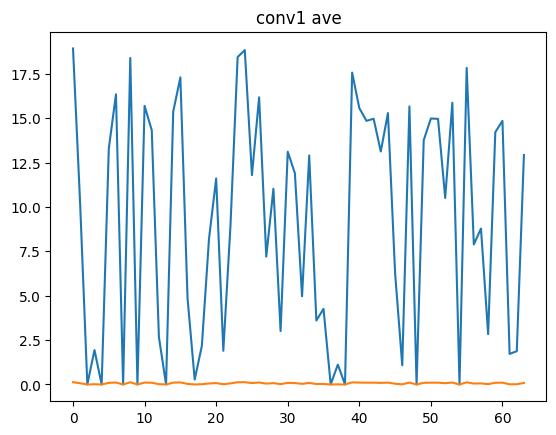

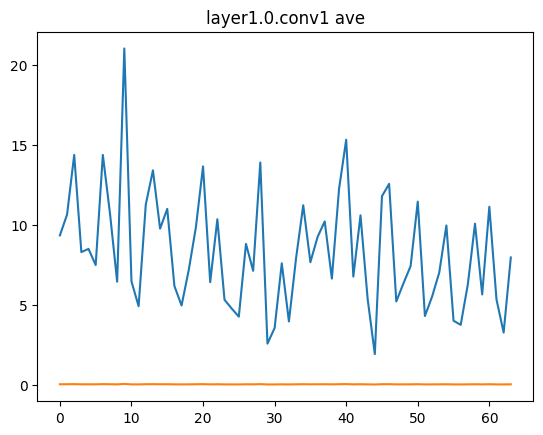

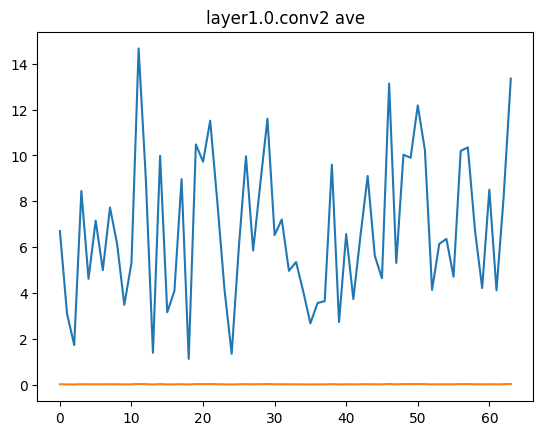

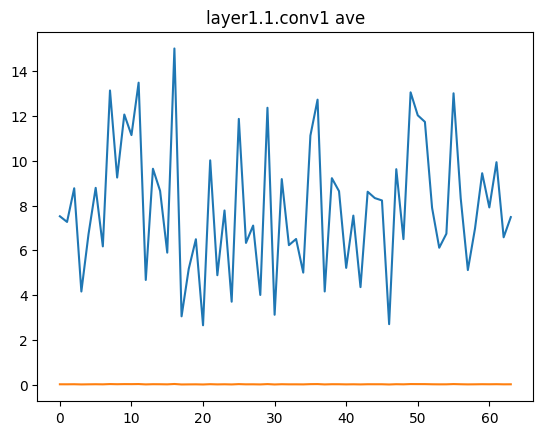

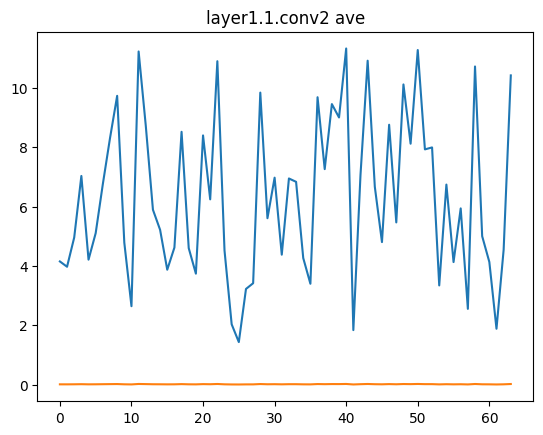

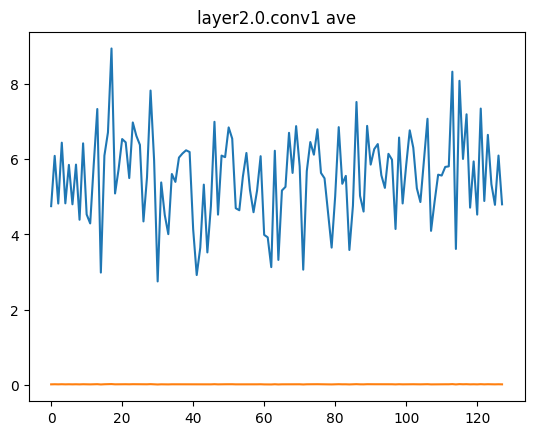

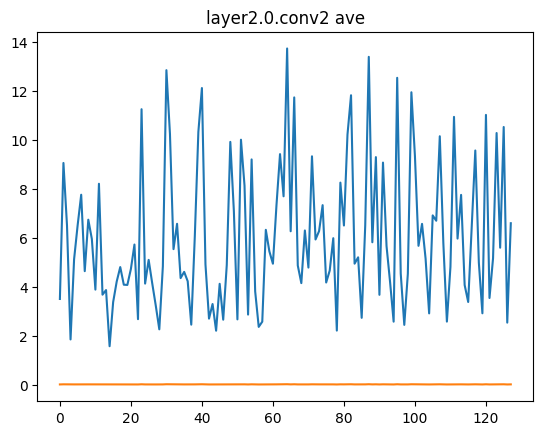

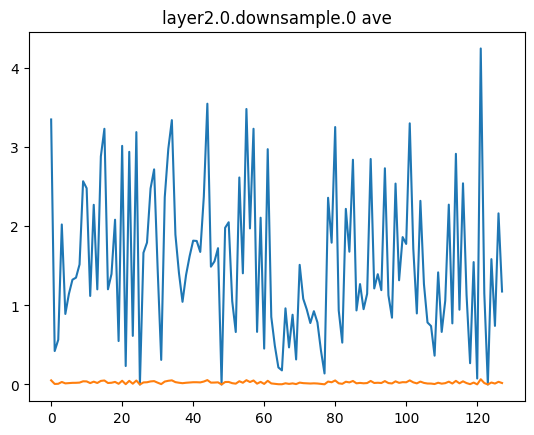

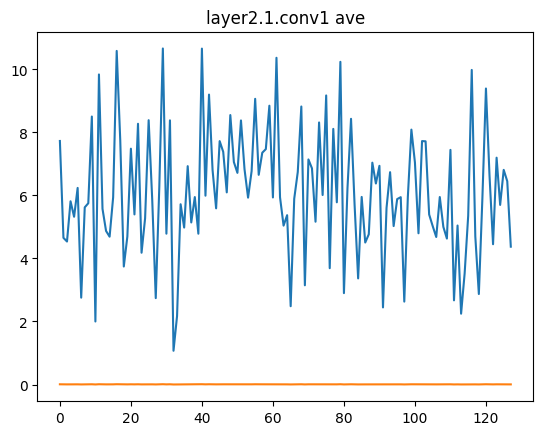

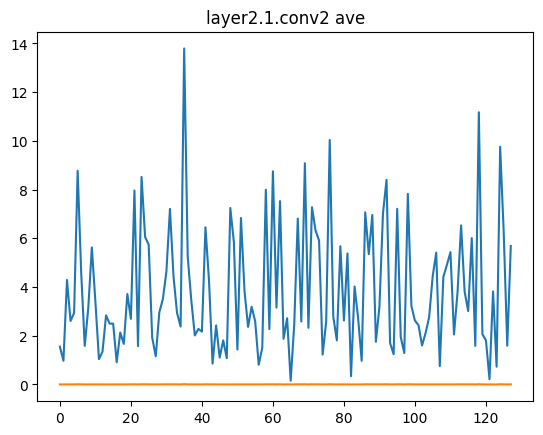

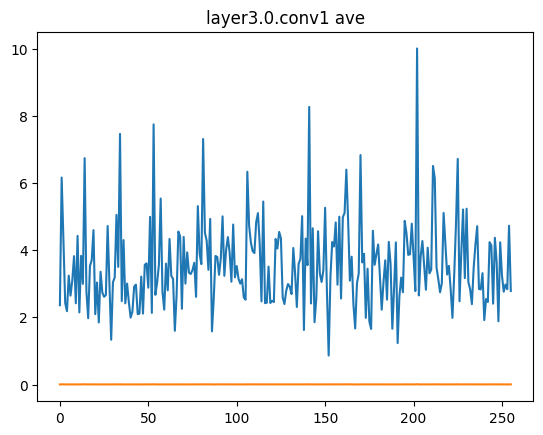

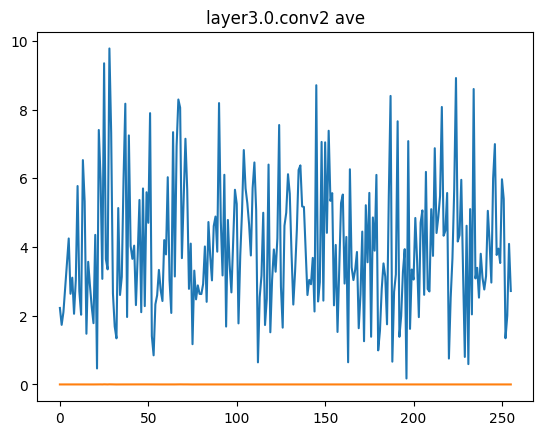

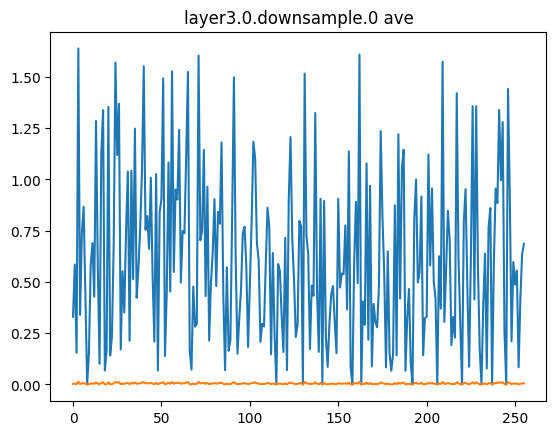

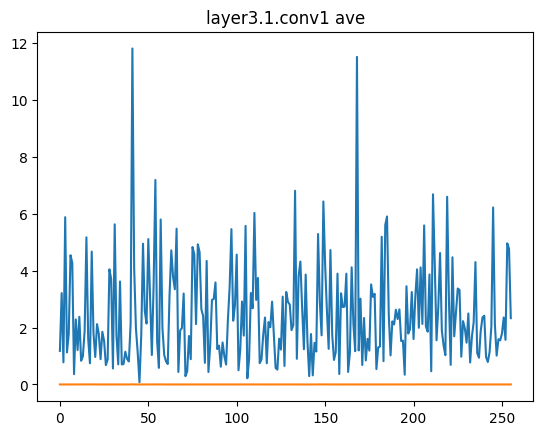

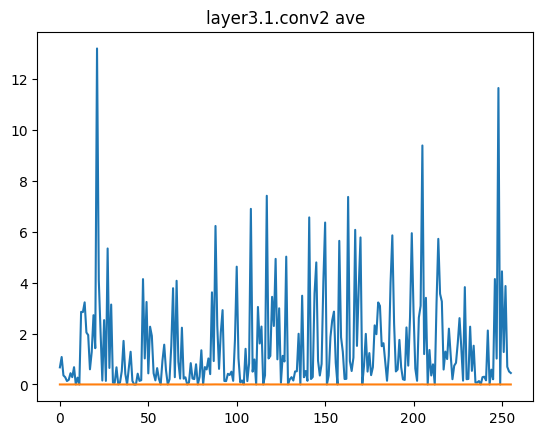

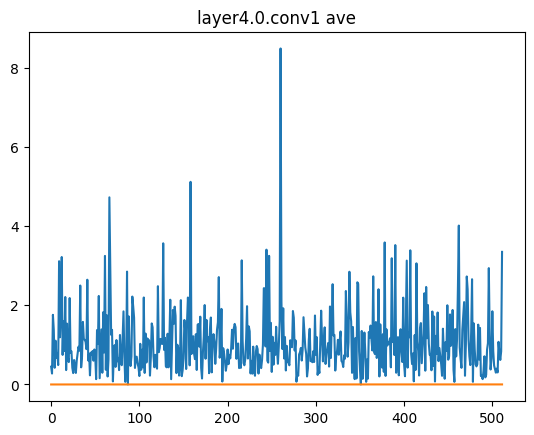

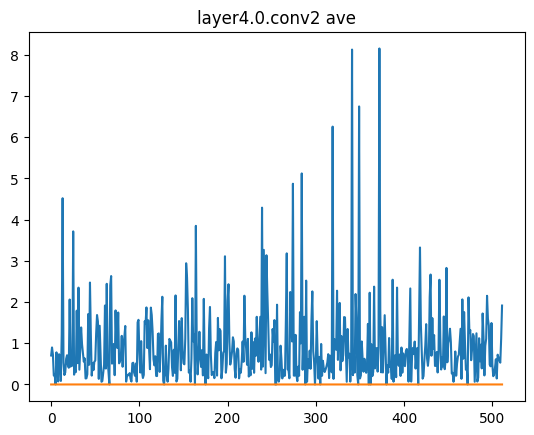

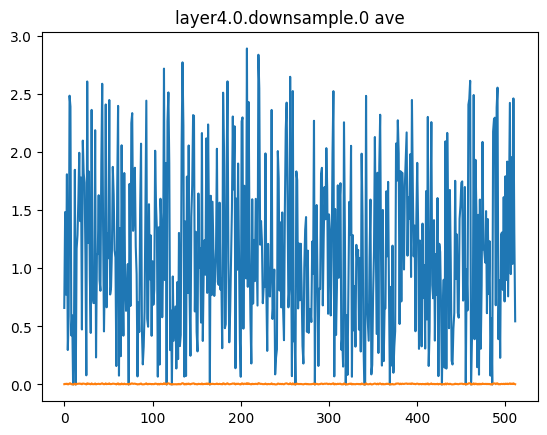

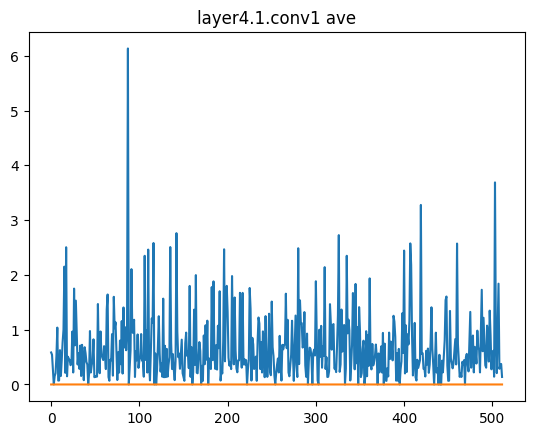

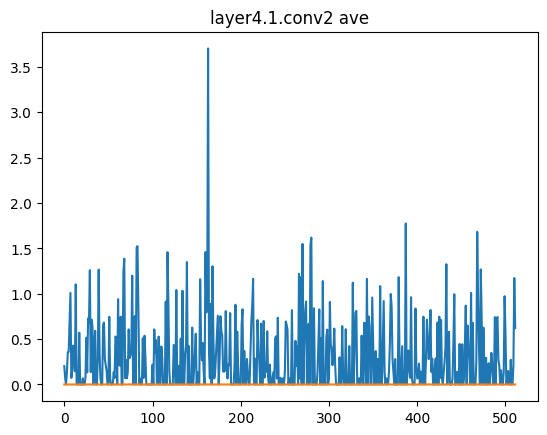

辞書を保存しました。


In [12]:
# フィルターごとの重み合計や平均を見る
AllLayer_filter_sum={}

for name, module in model.named_modules():
    if isinstance(module, nn.Conv2d):
        # 重みテンソルを取得 (out_channels, in_channels, h, w)
        weight = module.weight.detach()
        
        # フィルター（out_channels次元）ごとに、絶対値の合計を計算
        # dim=(1,2,3) は in_channels, height, width の次元を潰すという意味
        filter_sum = torch.sum(torch.abs(weight), dim=(1, 2, 3))
        filter_ave = filter_sum / (weight.size()[1]*weight.size()[2]*weight.size()[3])
        AllLayer_filter_sum[name] = filter_sum.tolist()

        plt.plot(filter_sum)
        #plt.ylim(-0.1, 0.2)
        plt.title(name+" sum")
        #plt.show()
        plt.plot(filter_ave)
        plt.title(name+" ave")
        #plt.ylim(-0, 0.01)
        plt.show()

import json

# 辞書をJSONファイルに書き出す
with open('../その他/kyodo_filterSum.json', 'w') as f:
    json.dump(AllLayer_filter_sum, f, indent=4) # indent=4できれいに整形

print("辞書を保存しました。")